In [17]:
import zipfile
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use(['default', 'science', 'no-latex'])

from code_utils.powerlaw_fitting import degree_frequency_distribution, fit_powerlaw, powerlaw_func
from code_utils.utils_basic import PROJECT_PATH

In [18]:
def load_csv_from_zip(zip_path, csv_path, **kwargs):
    """
    Load a CSV file from a ZIP archive into a pandas DataFrame.
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(csv_path) as f:
            df = pd.read_csv(f, **kwargs)
    return df

# 1. Load data

In [19]:
zip_path = PROJECT_PATH / 'data/features.zip'

# L-space node degree
l_space = load_csv_from_zip(
    zip_path,
    csv_path = 'space_l_node_topology.csv',
    index_col = 0, header = 0,
    dtype = {'pt_code': str})

# P-space node degree
p_space = load_csv_from_zip(
    zip_path,
    csv_path = 'space_p_node_topology.csv',
    index_col=0, header=0,
    dtype = {'pt_code': str})

# Merge L-space and P-space degree
topology = (pd.merge(
        l_space.add_prefix('l_'),
        p_space.add_prefix('p_'),
        left_index = True,
        right_index = True,)
    .sort_index()
)

print('\nData info:',
    '\nData shape:', topology.shape,
    '\nColumns:', topology.columns.tolist(),
    '\nNA values:', topology.isna().sum().sum(),)


Data info: 
Data shape: (5074, 20) 
Columns: ['l_in_degree_centrality', 'l_out_degree_centrality', 'l_in_eigenvector_centrality', 'l_out_eigenvector_centrality', 'l_in_katz_centrality', 'l_out_katz_centrality', 'l_closeness_centrality', 'l_betweenness_centrality', 'l_clustering_coefficient', 'l_pagerank', 'p_in_degree_centrality', 'p_out_degree_centrality', 'p_in_eigenvector_centrality', 'p_out_eigenvector_centrality', 'p_in_katz_centrality', 'p_out_katz_centrality', 'p_closeness_centrality', 'p_betweenness_centrality', 'p_clustering_coefficient', 'p_pagerank'] 
NA values: 0


# 2. Plot degree distribution with powerlaw fitting

In [20]:
def plot_powerlaw_fitting(x, y, ax=None):

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    ax.scatter(x, y, s=10, alpha=0.7, marker='o', edgecolor='white')

    # Log-log axes for power-law visualization
    ax.set_xscale("log", nonpositive='clip')
    ax.set_yscale("log", nonpositive='clip')
    ax.set_xlabel(r'Node degree')
    ax.set_ylabel(r'Frequency')

    # Fit powerlaw
    gamma, log_const = fit_powerlaw(x, y)
    const = np.exp(log_const)

    # plot fitted powerlaw
    y_fit = powerlaw_func(x, gamma, const)
    ax.plot(x, y_fit, color='red', lw=1.5, alpha=0.7)

    # R-squared, goodness of fit
    r_squared = np.corrcoef(y, y_fit)[0, 1]**2

    # Add text box with fit parameters
    textstr = (
        rf'$P(k) = {const:.3f} \cdot k^{{-{gamma:.3f}}}$' '\n'
        rf'$R^2 = {r_squared:.3f}$'
    )

    ax.text(
        0.05, 0.05, textstr,
        transform=ax.transAxes,
        fontsize = 11,
        va = 'bottom', ha = 'left',
    )

    return ax

In [21]:
degree = (topology[[
        'l_in_degree_centrality', 'l_out_degree_centrality',
        'p_in_degree_centrality', 'p_out_degree_centrality',]]
    .copy()
    .rename(columns={
        'l_in_degree_centrality' : 'l_dc_in',
        'l_out_degree_centrality': 'l_dc_out',
        'p_in_degree_centrality' : 'p_dc_in',
        'p_out_degree_centrality': 'p_dc_out',})
)

print('\nData info:',
    '\nData shape:', degree.shape,
    '\nColumns:', degree.columns.tolist(),
    '\nNA values:', degree.isna().sum().sum(),)


Data info: 
Data shape: (5074, 4) 
Columns: ['l_dc_in', 'l_dc_out', 'p_dc_in', 'p_dc_out'] 
NA values: 0


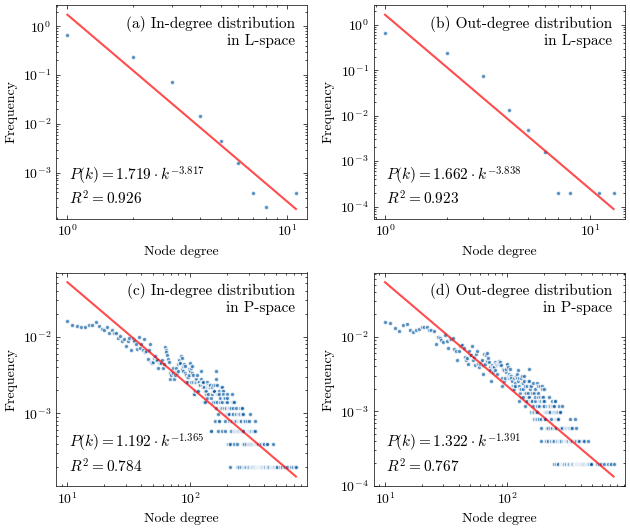

In [22]:
# figure config
fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.5))
axes = axes.flatten()

for _ix, _col in enumerate(['l_dc_in', 'l_dc_out', 'p_dc_in', 'p_dc_out']):

    if _col in ['l_dc_in', 'l_dc_out']:
        trunc_threshold = 1
    else:
        trunc_threshold = 10

    # Get sample
    sample = degree[_col].copy()
    # Compute degree distribution
    x, y = degree_frequency_distribution(sample, trunc_threshold=trunc_threshold)

    ax = axes[_ix]
    ax = plot_powerlaw_fitting(x, y, ax=ax)

    # Add caption
    if _col == 'l_dc_in':
        strcaption = '(a) In-degree distribution\nin L-space'
    elif _col == 'l_dc_out':
        strcaption = '(b) Out-degree distribution\nin L-space'
    elif _col == 'p_dc_in':
        strcaption = '(c) In-degree distribution\nin P-space'
    elif _col == 'p_dc_out':
        strcaption = '(d) Out-degree distribution\nin P-space'

    ax.text(
        0.95, 0.95, strcaption,
        transform=ax.transAxes,
        fontsize = 11,
        va = 'top', ha = 'right',
    )


fig.tight_layout()
# Save figure
# fig.savefig('degree_distribution_powerlaw_fitting.pdf')
# fig.savefig('degree_distribution_powerlaw_fitting.jpg', dpi=600)

# 2. Distribution histogram

In [23]:
col_li = [
    'closeness_centrality',
    'betweenness_centrality',
    'in_eigenvector_centrality', 'out_eigenvector_centrality',
    'in_katz_centrality', 'out_katz_centrality',
    'pagerank',
    'clustering_coefficient']

label_li = {
    'closeness_centrality'       : 'Closeness centrality',
    'betweenness_centrality'     : 'Betweenness centrality',
    'in_eigenvector_centrality'  : 'In-eigenvector centrality',
    'out_eigenvector_centrality' : 'Out-eigenvector centrality',
    'in_katz_centrality'         : 'In-Katz centrality',
    'out_katz_centrality'        : 'Out-Katz centrality',
    'pagerank'                   : 'PageRank',
    'clustering_coefficient'     : 'Clustering coefficient',
}

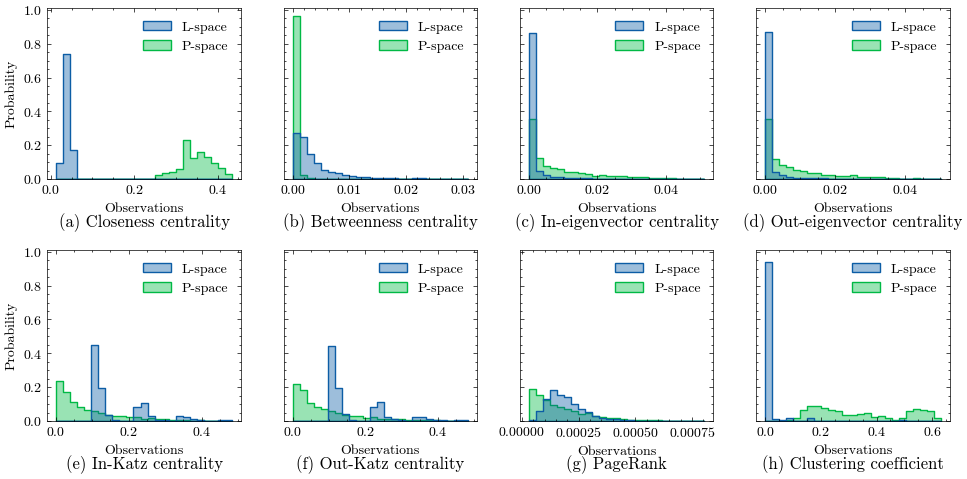

In [24]:
# Figure config
fig, axes = plt.subplots(2, 4, figsize=(10, 5), sharey=True)
axes = axes.flatten()

for _ix, _col in enumerate(col_li):
    # Prepare data for plotting
    _cols = [f'l_{_col}', f'p_{_col}']
    data_plot = topology[_cols].copy()

    data_plot.index.name = 'pt_code'
    data_plot.columns.name = 'feature'

    data_plot = data_plot.stack()
    data_plot.name = 'value'

    data_plot = (data_plot
        .reset_index()
        .assign(space = lambda df: df['feature'].str[:1].str.upper() + '-space')
        .assign(topology = lambda df: df['feature'].str[2:])
    )

    # Remove long-tail values for better visualization
    data_plot = data_plot[data_plot['value'] < data_plot['value'].quantile(0.99)]


    # Plot histogram
    ax = axes[_ix]
    ax = sns.histplot(data = data_plot, x = 'value', hue = 'space',
        stat = 'probability',
        bins = 25,
        common_norm = False, kde = False, alpha = 0.4, element = "step",
        ax = ax,
        line_kws = {'linewidth' : None}
    )
    ax.set_xlabel('Observations')

    # remove legend title
    ax.get_legend().set_title(None)

    # Add figure caption
    ax.text(
        0.5, -0.20, f'({chr(97+_ix)}) {label_li[_col]}',
        transform = ax.transAxes,
        fontsize = 12,
        va = 'top', ha = 'center',
    )

fig.tight_layout(w_pad=0.00, h_pad=1.)

# Save figure
# fig.savefig(SAVE_FOLDER / 'centrality_distribution_histogram.jpg', dpi=600)
# fig.savefig(SAVE_FOLDER / 'centrality_distribution_histogram.pdf',)